In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#chart style
plt.figure(figsize=(10,5))
sns.set_style("whitegrid")
print("success")

success


<Figure size 1000x500 with 0 Axes>

In [3]:
#load dataset
df_raw = pd.read_csv('ecommerce_sales_34500.csv')

In [4]:
#initial inspection
df_raw.shape

(34500, 17)

In [8]:
df_raw.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male


In [9]:
df_raw.columns

Index(['order_id', 'customer_id', 'product_id', 'category', 'price',
       'discount', 'quantity', 'payment_method', 'order_date',
       'delivery_time_days', 'region', 'returned', 'total_amount',
       'shipping_cost', 'profit_margin', 'customer_age', 'customer_gender'],
      dtype='str')

In [10]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            34500 non-null  str    
 1   customer_id         34500 non-null  str    
 2   product_id          34500 non-null  str    
 3   category            34500 non-null  str    
 4   price               34500 non-null  float64
 5   discount            34500 non-null  float64
 6   quantity            34500 non-null  int64  
 7   payment_method      34500 non-null  str    
 8   order_date          34500 non-null  str    
 9   delivery_time_days  34500 non-null  int64  
 10  region              34500 non-null  str    
 11  returned            34500 non-null  str    
 12  total_amount        34500 non-null  float64
 13  shipping_cost       34500 non-null  float64
 14  profit_margin       34500 non-null  float64
 15  customer_age        34500 non-null  int64  
 16  customer_gender

In [11]:
df_raw.describe()

,price,discount,quantity,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age
count,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000
mean,119.391632,0.049291,1.490725,4.814203,170.008494,6.152120,28.116505,43.474377
std,195.620477,0.069894,0.932270,1.242141,357.503014,2.389539,53.352947,14.980682
min,1.010000,0.000000,1.000000,3.000000,0.820000,0.000000,-6.200000,18.000000
25%,16.690000,0.000000,1.000000,4.000000,19.710000,4.420000,1.500000,31.000000
50%,45.660000,0.000000,1.000000,5.000000,56.820000,6.090000,10.550000,43.000000
75%,130.950000,0.100000,2.000000,6.000000,168.530000,7.830000,33.132500,56.000000
max,2930.470000,0.300000,5.000000,13.000000,12931.800000,15.650000,1536.170000,69.000000


In [5]:
# create a copy before starting
df = df_raw.copy()

In [6]:
# check null values
df.isnull().sum()

order_id              0
customer_id           0
product_id            0
category              0
price                 0
discount              0
quantity              0
payment_method        0
order_date            0
delivery_time_days    0
region                0
returned              0
total_amount          0
shipping_cost         0
profit_margin         0
customer_age          0
customer_gender       0
dtype: int64

In [14]:
# check full duplicates
df.duplicated().sum()

np.int64(0)

In [15]:
# check key duplicates
df['order_id'].duplicated().sum()

np.int64(0)

In [8]:
# fix datatypes
df['order_date'] = pd.to_datetime(df['order_date'])

In [17]:
df.dtypes

order_id                         str
customer_id                      str
product_id                       str
category                         str
price                        float64
discount                     float64
quantity                       int64
payment_method                   str
order_date            datetime64[us]
delivery_time_days             int64
region                           str
returned                         str
total_amount                 float64
shipping_cost                float64
profit_margin                float64
customer_age                   int64
customer_gender                  str
dtype: object

In [19]:
# validate numeric columns
df[df['price'] < 0]

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender


In [21]:
df[df['quantity'] <= 0]

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender


In [22]:
df[df['delivery_time_days'] < 0]

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender


In [23]:
df[df['total_amount'] <= 0]

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender


In [24]:
df[df['shipping_cost'] < 0]

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender


In [25]:
df[(df['customer_age'] < 10) | (df['customer_age'] > 100)]

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender


In [28]:
df[(df['discount'] < 0) | (df['discount'] > 1)]

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender


In [33]:
# validate categorical columns
df['payment_method'].unique()

<StringArray>
['Credit Card', 'UPI', 'COD', 'PayPal', 'Debit Card', 'Wallet']
Length: 6, dtype: str

In [35]:
df['category'].unique()

<StringArray>
['Home', 'Grocery', 'Electronics', 'Beauty', 'Fashion', 'Toys', 'Sports']
Length: 7, dtype: str

In [36]:
df['region'].unique()

<StringArray>
['West', 'South', 'North', 'East', 'Central']
Length: 5, dtype: str

In [37]:
df['returned'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [38]:
df['customer_gender'].unique()

<StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str

In [39]:
#standardize text column
std_col = ['category', 'payment_method', 'region', 'returned', 'customer_gender']
for col in std_col:
    df[col] = (df[col].astype(str).str.strip().str.title())

In [40]:
df['payment_method'] = df['payment_method'].replace({'Upi' : 'UPI', 'Cod' : 'COD'})

In [9]:
# create needed columns
df['year'] = df['order_date'].dt.year

In [10]:
df['month_name'] = df['order_date'].dt.month_name()

In [11]:
df

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender,year,month_name
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female,2023,December
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male,2025,April
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male,2024,October
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female,2024,September
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male,2024,December
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34495,O134495,C13553,P231412,Fashion,10.44,0.20,1,Debit Card,2025-08-13,3,North,No,8.35,3.04,-0.12,23,Female,2025,August
34496,O134496,C11349,P218266,Beauty,4.79,0.10,5,Debit Card,2023-12-04,6,South,Yes,21.56,3.37,6.33,61,Female,2023,December
34497,O134497,C12986,P204345,Electronics,323.64,0.00,5,Credit Card,2025-02-01,6,East,No,1618.20,12.18,182.00,41,Female,2025,February
34498,O134498,C17196,P217644,Home,23.09,0.05,1,Credit Card,2024-03-27,6,East,No,21.94,5.61,0.53,27,Female,2024,March


In [46]:
#validate revenue logic
expected_total_amount = (df['price'] * df['quantity'] * (1- df['discount']))

In [47]:
diff = expected_total_amount - df['total_amount']

In [48]:
df[diff > 1]

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender,year,month_name


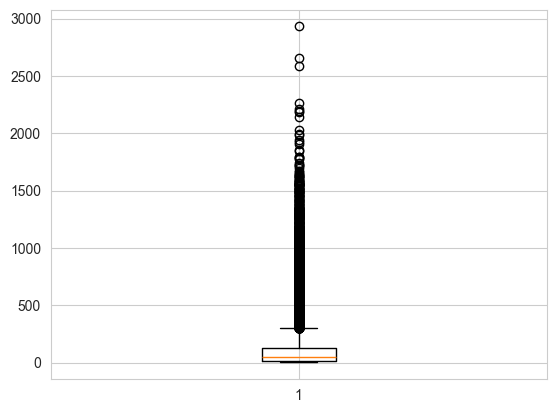

In [50]:
#check outliers
plt.boxplot(df['price'])
plt.show()

In [51]:
# IQR outlier detection
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['price'] < lower) | (df['price'] > upper)]
outliers.shape

(3632, 19)

In [52]:
#check return rate consistency
df['returned'].value_counts()

returned
No     32597
Yes     1903
Name: count, dtype: int64

In [54]:
# return percentage
df['returned'].value_counts(normalize=True) * 100
# value_counts(dropna=False)

returned
No     94.484058
Yes     5.515942
Name: proportion, dtype: float64

In [55]:
#final data validation
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            34500 non-null  str           
 1   customer_id         34500 non-null  str           
 2   product_id          34500 non-null  str           
 3   category            34500 non-null  str           
 4   price               34500 non-null  float64       
 5   discount            34500 non-null  float64       
 6   quantity            34500 non-null  int64         
 7   payment_method      34500 non-null  str           
 8   order_date          34500 non-null  datetime64[us]
 9   delivery_time_days  34500 non-null  int64         
 10  region              34500 non-null  str           
 11  returned            34500 non-null  str           
 12  total_amount        34500 non-null  float64       
 13  shipping_cost       34500 non-null  float64       
 14  p

In [56]:
df.describe(include = 'all')

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender,year,month_name
count,34500,34500,34500,34500,34500.000000,34500.000000,34500.000000,34500,34500,34500.000000,34500,34500,34500.000000,34500.000000,34500.000000,34500.000000,34500,34500.000000,34500
unique,34500,7903,24912,7,NaN,NaN,NaN,6,NaN,NaN,5,2,NaN,NaN,NaN,NaN,3,NaN,12
top,O100000,C11573,P200645,Fashion,NaN,NaN,NaN,Credit Card,NaN,NaN,South,No,NaN,NaN,NaN,NaN,Female,NaN,July
freq,1,13,7,6254,NaN,NaN,NaN,12170,NaN,NaN,7584,32597,NaN,NaN,NaN,NaN,16818,NaN,2972
mean,NaN,NaN,NaN,NaN,119.391632,0.049291,1.490725,NaN,2024-09-13 13:39:17.843478,4.814203,NaN,NaN,170.008494,6.152120,28.116505,43.474377,NaN,2024.200319,NaN
min,NaN,NaN,NaN,NaN,1.010000,0.000000,1.000000,NaN,2023-09-12 00:00:00,3.000000,NaN,NaN,0.820000,0.000000,-6.200000,18.000000,NaN,2023.000000,NaN
25%,NaN,NaN,NaN,NaN,16.690000,0.000000,1.000000,NaN,2024-03-14 00:00:00,4.000000,NaN,NaN,19.710000,4.420000,1.500000,31.000000,NaN,2024.000000,NaN
50%,NaN,NaN,NaN,NaN,45.660000,0.000000,1.000000,NaN,2024-09-16 00:00:00,5.000000,NaN,NaN,56.820000,6.090000,10.550000,43.000000,NaN,2024.000000,NaN
75%,NaN,NaN,NaN,NaN,130.950000,0.100000,2.000000,NaN,2025-03-17 00:00:00,6.000000,NaN,NaN,168.530000,7.830000,33.132500,56.000000,NaN,2025.000000,NaN
max,NaN,NaN,NaN,NaN,2930.470000,0.300000,5.000000,NaN,2025-09-11 00:00:00,13.000000,NaN,NaN,12931.800000,15.650000,1536.170000,69.000000,NaN,2025.000000,NaN


In [57]:
df.isnull().sum()

order_id              0
customer_id           0
product_id            0
category              0
price                 0
discount              0
quantity              0
payment_method        0
order_date            0
delivery_time_days    0
region                0
returned              0
total_amount          0
shipping_cost         0
profit_margin         0
customer_age          0
customer_gender       0
year                  0
month_name            0
dtype: int64

In [59]:
# EDA
# kpi
# total revenue
df['total_amount'].sum()

np.float64(5865293.05)

In [60]:
#average order value
df['total_amount'].mean()

np.float64(170.00849420289853)

In [61]:
#total profit
df['profit_margin'].sum()

np.float64(970019.41)

In [62]:
# total products sold
df['quantity'].sum()

np.int64(51430)

In [63]:
#total customers
df['customer_id'].nunique()

7903

In [64]:
# total orders
df['order_id'].nunique()

34500

In [65]:
# univariate
df.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender,year,month_name
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female,2023,December
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male,2025,April
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male,2024,October
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female,2024,September
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male,2024,December


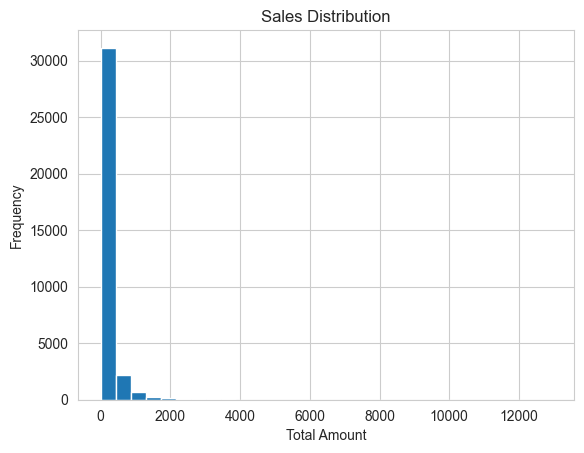

In [71]:
#Initial sales distribution (with outliers) -- hard to see details due to heavily right skewed
plt.hist(df['total_amount'], bins=30)
plt.xlabel('Total Amount')
plt.ylabel('Frequency')
plt.title('Initial Sales Distribution')
plt.show()

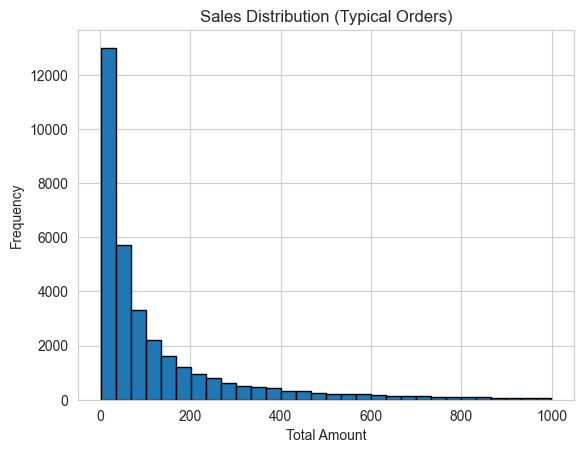

In [75]:
# filter for amounts under 1000
typical_sales= df[df['total_amount']<1000]['total_amount']
plt.hist(typical_sales, bins=30, edgecolor='black')
plt.xlabel('Total Amount')
plt.ylabel('Frequency')
plt.title('Sales Distribution (Typical Orders)')
plt.show()

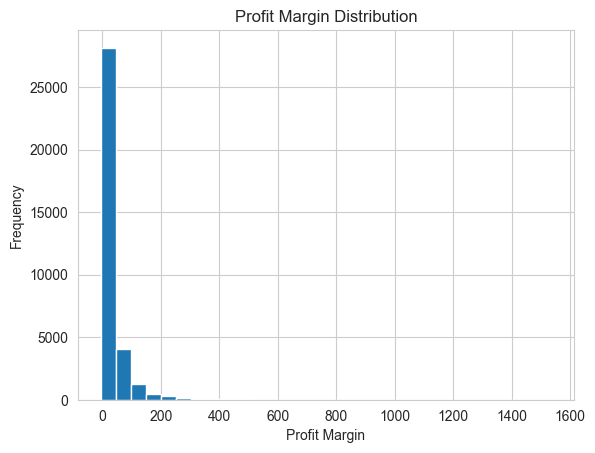

In [77]:
# initial distribution with outliers
plt.hist(df['profit_margin'], bins=30)
plt.xlabel('Profit Margin')
plt.ylabel('Frequency')
plt.title('Profit Margin Distribution')
plt.show()

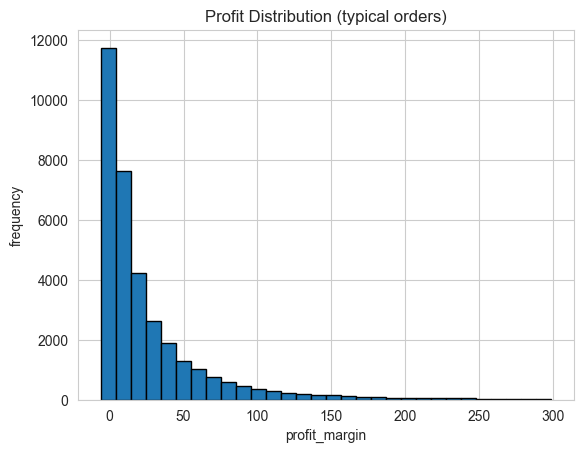

In [81]:
# filter for profits under 200
typical_profits = df[df['profit_margin'] < 300]['profit_margin']
plt.hist(typical_profits, bins=30, edgecolor= 'black')
plt.xlabel('profit_margin')
plt.ylabel('frequency')
plt.title('Profit Distribution (typical orders)')
plt.show()

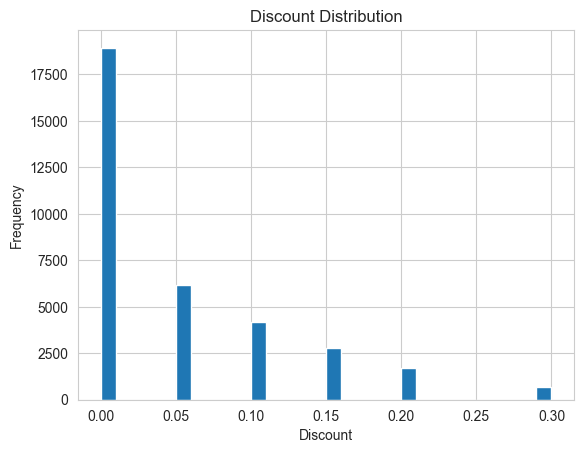

In [158]:
plt.hist(df['discount'], bins=30)
plt.xlabel('Discount')
plt.ylabel('Frequency')
plt.title('Discount Distribution')
plt.show()

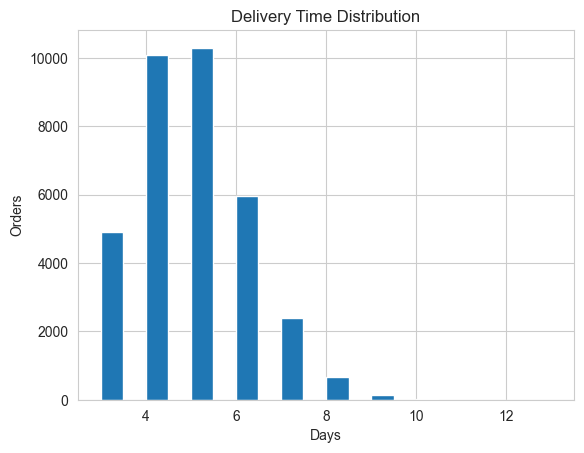

In [159]:
plt.hist(df['delivery_time_days'], bins=20)
plt.xlabel('Days')
plt.ylabel('Orders')
plt.title('Delivery Time Distribution')
plt.show()

In [82]:
df['category'].value_counts()

category
Fashion        6254
Electronics    6180
Home           5487
Toys           4247
Sports         4171
Beauty         4103
Grocery        4058
Name: count, dtype: int64

In [84]:
df['region'].value_counts()

region
South      7584
North      7572
East       6904
West       6808
Central    5632
Name: count, dtype: int64

In [85]:
df['returned'].value_counts()

returned
No     32597
Yes     1903
Name: count, dtype: int64

In [86]:
(df['returned'].value_counts(normalize=True)) * 100

returned
No     94.484058
Yes     5.515942
Name: proportion, dtype: float64

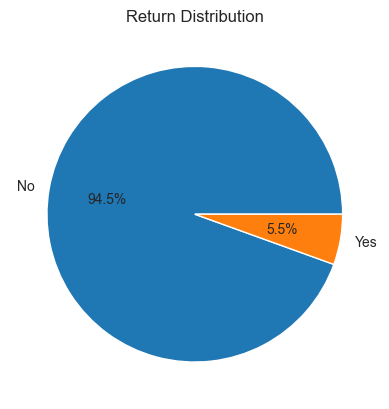

In [92]:
df['returned'].value_counts().plot(kind='pie', autopct= '%.1f%%')
plt.title('Return Distribution')
plt.show()

In [88]:
df['payment_method'].value_counts()

payment_method
Credit Card    12170
Debit Card      8505
COD             4160
UPI             4156
Paypal          3444
Wallet          2065
Name: count, dtype: int64

In [93]:
#bivariate
df.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender,year,month_name
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female,2023,December
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male,2025,April
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male,2024,October
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female,2024,September
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male,2024,December


In [94]:
# which product category is generating the most revenue
df.groupby('category')['total_amount'].sum().sort_values(ascending=False)

category
Electronics    3319206.50
Home           1077681.52
Sports          629825.54
Fashion         471545.80
Beauty          153019.38
Toys            132013.80
Grocery          82000.51
Name: total_amount, dtype: float64

In [95]:
# which product categpory is generating the most profit
df.groupby('category')['profit_margin'].sum().sort_values(ascending=False)

category
Electronics    344371.77
Home           262633.70
Sports         160521.41
Fashion        128814.65
Beauty          49196.59
Toys            33669.25
Grocery         -9187.96
Name: profit_margin, dtype: float64

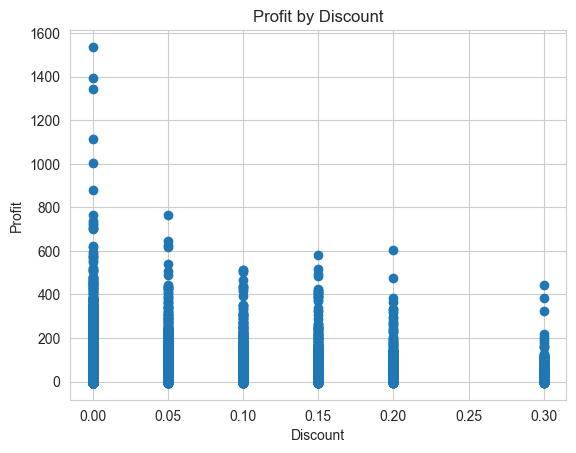

In [97]:
# Are discounts destroying profitability
plt.scatter(df['discount'], df['profit_margin'])
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Profit by Discount')
plt.show()

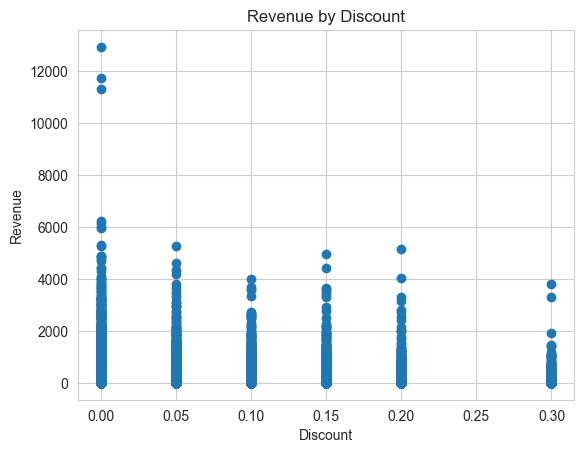

In [98]:
# are discounts increasing sales
plt.scatter(df['discount'], df['total_amount'])
plt.xlabel('Discount')
plt.ylabel('Revenue')
plt.title('Revenue by Discount')
plt.show()

In [99]:
# which region generates the most sales
df.groupby('region')['total_amount'].sum().sort_values(ascending=False)

region
South      1298096.07
North      1264008.35
West       1186350.50
East       1176334.75
Central     940503.38
Name: total_amount, dtype: float64

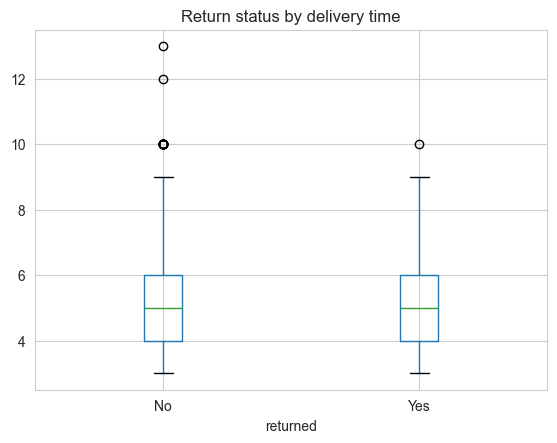

In [101]:
#  are delivery time impacting returns
df.boxplot(column= 'delivery_time_days', by='returned')
plt.title('Return status by delivery time')
plt.suptitle('')
plt.show()

In [104]:
# which category seeing most returns
df.groupby('category')['returned'].value_counts(normalize=True).loc[:,'Yes'].sort_values(ascending=False)

category
Fashion        0.082827
Electronics    0.072977
Home           0.056497
Toys           0.049447
Sports         0.049389
Beauty         0.037777
Grocery        0.013061
Name: proportion, dtype: float64

In [109]:
# which region have highest return problems
df.groupby('region')['returned'].value_counts(normalize=True).loc[:, 'Yes'].sort_values(ascending=False)

region
East       0.059096
South      0.056830
West       0.054495
North      0.053619
Central    0.050959
Name: proportion, dtype: float64

In [110]:
# which gender is buying the most
df.groupby('customer_gender')['total_amount'].sum().sort_values(ascending= False)

customer_gender
Female    2853296.96
Male      2793055.33
Other      218940.76
Name: total_amount, dtype: float64

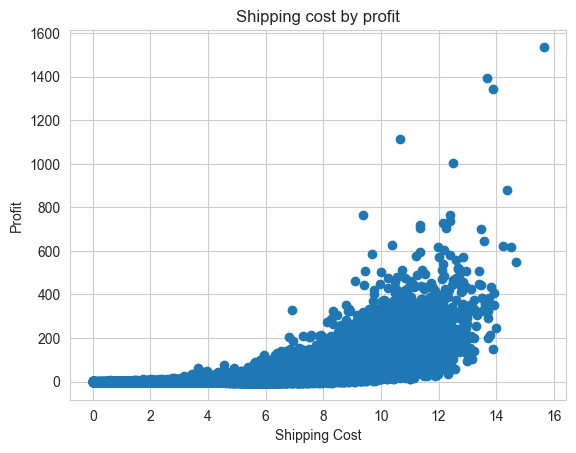

In [111]:
# is shipping cost reducing profit
plt.scatter(df['shipping_cost'], df['profit_margin'])
plt.xlabel('Shipping Cost')
plt.ylabel('Profit')
plt.title('Shipping cost by profit')
plt.show()    

In [12]:
# 3 variate
# which categories are most profitable in each region
(df.groupby(['region', 'category'])['profit_margin'].sum().reset_index().sort_values(['category','profit_margin'],ascending=False))

,region,category,profit_margin
20,North,Toys,8071.69
27,South,Toys,7603.43
13,East,Toys,6505.75
34,West,Toys,6140.69
6,Central,Toys,5347.69
26,South,Sports,37894.10
33,West,Sports,33801.32
19,North,Sports,31875.88
12,East,Sports,30367.63
5,Central,Sports,26582.48


In [117]:
# which categories are over-discounted and under-profitable
(df.groupby(['category','discount'])
    .agg(avg_profit=('profit_margin', 'mean'),
         total_sales=('total_amount', 'sum')).reset_index())

,category,discount,avg_profit,total_sales
0,Beauty,0.00,12.857324,87846.12
1,Beauty,0.05,12.424780,28836.70
2,Beauty,0.10,11.381020,17922.10
3,Beauty,0.15,10.162216,10962.93
4,Beauty,0.20,8.007574,5594.10
5,Beauty,0.30,5.631412,1857.43
6,Electronics,0.00,60.068965,1895549.21
7,Electronics,0.05,51.661864,569426.23
8,Electronics,0.10,50.975816,389636.02
9,Electronics,0.15,52.411488,256470.50


In [134]:
# which category is generating profit but not revenue
(df.groupby('category').agg(revenue=('total_amount','sum'), profit=('profit_margin','sum'))
    .reset_index().sort_values('revenue',ascending=False))

,category,revenue,profit
1,Electronics,3319206.50,344371.77
4,Home,1077681.52,262633.70
5,Sports,629825.54,160521.41
2,Fashion,471545.80,128814.65
0,Beauty,153019.38,49196.59
6,Toys,132013.80,33669.25
3,Grocery,82000.51,-9187.96


In [152]:
# do heavily discounted bulk orders remain profitable in certain categories
(df.groupby(['category','discount','quantity']).agg(avg_profit=('profit_margin','mean')).reset_index().
    sort_values(['quantity','discount'],ascending=False)).head(20)

,category,discount,quantity,avg_profit
58,Electronics,0.30,5,134.774000
117,Grocery,0.30,5,-3.830000
147,Home,0.30,5,129.423333
177,Sports,0.30,5,18.320000
207,Toys,0.30,5,12.697500
24,Beauty,0.20,5,21.964286
53,Electronics,0.20,5,178.690000
83,Fashion,0.20,5,174.103333
112,Grocery,0.20,5,-1.440000
142,Home,0.20,5,129.694000


In [119]:
# time series analysis
df['year_month'] = df['order_date'].dt.to_period('M')
df

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender,year,month_name,year_month
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female,2023,December,2023-12
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male,2025,April,2025-04
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male,2024,October,2024-10
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female,2024,September,2024-09
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male,2024,December,2024-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34495,O134495,C13553,P231412,Fashion,10.44,0.20,1,Debit Card,2025-08-13,3,North,No,8.35,3.04,-0.12,23,Female,2025,August,2025-08
34496,O134496,C11349,P218266,Beauty,4.79,0.10,5,Debit Card,2023-12-04,6,South,Yes,21.56,3.37,6.33,61,Female,2023,December,2023-12
34497,O134497,C12986,P204345,Electronics,323.64,0.00,5,Credit Card,2025-02-01,6,East,No,1618.20,12.18,182.00,41,Female,2025,February,2025-02
34498,O134498,C17196,P217644,Home,23.09,0.05,1,Credit Card,2024-03-27,6,East,No,21.94,5.61,0.53,27,Female,2024,March,2024-03


In [120]:
df.groupby('year_month')['total_amount'].sum()

year_month
2023-09    151135.60
2023-10    262502.74
2023-11    240286.91
2023-12    255617.03
2024-01    217766.09
2024-02    228013.98
2024-03    248176.28
2024-04    265596.66
2024-05    264875.23
2024-06    234155.38
2024-07    253369.40
2024-08    212613.20
2024-09    218873.90
2024-10    258931.27
2024-11    250572.04
2024-12    278154.19
2025-01    224390.21
2025-02    215338.19
2025-03    239346.81
2025-04    263024.03
2025-05    248527.46
2025-06    248776.28
2025-07    249593.50
2025-08    243808.50
2025-09     91848.17
Freq: M, Name: total_amount, dtype: float64

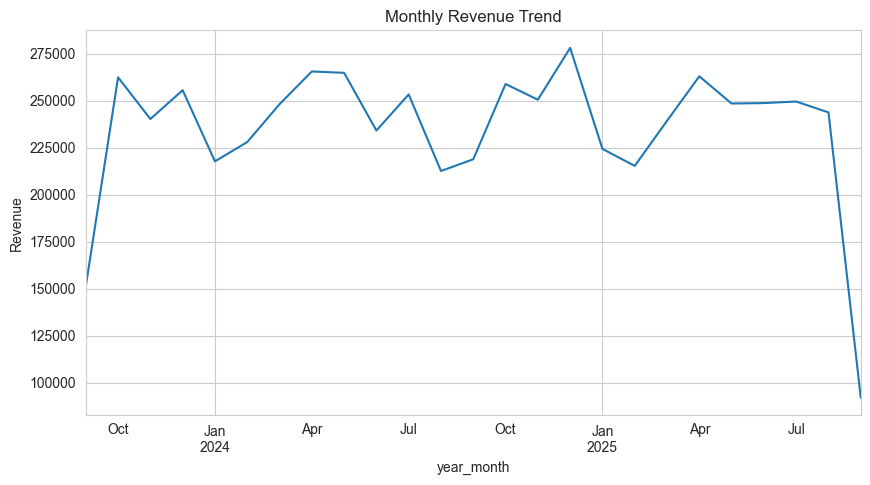

In [121]:
df.groupby('year_month')['total_amount'].sum().plot(kind='line', figsize=(10,5))
plt.ylabel('Revenue')
plt.title('Monthly Revenue Trend')
plt.show()

In [123]:
# are orders increasing over time
df.groupby('year_month')['order_id'].nunique()

year_month
2023-09     876
2023-10    1468
2023-11    1385
2023-12    1499
2024-01    1386
2024-02    1358
2024-03    1423
2024-04    1436
2024-05    1427
2024-06    1381
2024-07    1501
2024-08    1378
2024-09    1418
2024-10    1482
2024-11    1474
2024-12    1469
2025-01    1442
2025-02    1337
2025-03    1481
2025-04    1431
2025-05    1494
2025-06    1430
2025-07    1471
2025-08    1498
2025-09     555
Freq: M, Name: order_id, dtype: int64

In [124]:
# are profits increasing over time
df.groupby('year_month')['profit_margin'].sum()

year_month
2023-09    24346.72
2023-10    43048.19
2023-11    40044.23
2023-12    41385.45
2024-01    37604.38
2024-02    37826.96
2024-03    40763.26
2024-04    43663.68
2024-05    43821.21
2024-06    38279.76
2024-07    43370.56
2024-08    35632.19
2024-09    37072.16
2024-10    41708.59
2024-11    41444.89
2024-12    43061.35
2025-01    35957.55
2025-02    36201.17
2025-03    40072.27
2025-04    42124.49
2025-05    41577.66
2025-06    40917.99
2025-07    42909.79
2025-08    41457.69
2025-09    15727.22
Freq: M, Name: profit_margin, dtype: float64

In [126]:
# return rate over time
df.groupby('year_month')['returned'].apply(lambda x: (x == 'Yes').mean() * 100)

year_month
2023-09    4.452055
2023-10    5.040872
2023-11    5.270758
2023-12    5.603736
2024-01    5.339105
2024-02    5.007364
2024-03    6.465214
2024-04    6.337047
2024-05    5.395936
2024-06    4.779146
2024-07    5.529647
2024-08    5.370102
2024-09    6.558533
2024-10    5.263158
2024-11    5.563094
2024-12    6.058543
2025-01    4.576976
2025-02    5.983545
2025-03    4.591492
2025-04    5.730259
2025-05    5.756359
2025-06    5.874126
2025-07    5.982325
2025-08    5.407210
2025-09    5.585586
Freq: M, Name: returned, dtype: float64

In [127]:
# delivery trend over time
df.groupby('year_month')['delivery_time_days'].mean()

year_month
2023-09    4.759132
2023-10    4.790872
2023-11    4.852708
2023-12    4.858572
2024-01    4.843434
2024-02    4.843888
2024-03    4.765285
2024-04    4.825905
2024-05    4.805186
2024-06    4.787835
2024-07    4.854097
2024-08    4.776488
2024-09    4.864598
2024-10    4.815789
2024-11    4.843962
2024-12    4.812117
2025-01    4.826630
2025-02    4.813762
2025-03    4.807562
2025-04    4.800839
2025-05    4.806560
2025-06    4.827273
2025-07    4.768865
2025-08    4.765688
2025-09    4.823423
Freq: M, Name: delivery_time_days, dtype: float64

In [128]:
# are there certain months where the business is more flourishing
df.groupby('month_name')['total_amount'].mean().sort_values(ascending=False)

month_name
April        184.381127
December     179.842055
October      176.757292
May          175.762646
June         171.800662
November     171.689035
July         169.233816
March        167.879852
February     164.509154
September    162.112204
August       158.700174
January      156.349470
Name: total_amount, dtype: float64

In [160]:
df.to_csv('cleaned_ecommerce_sales.csv', index=False)